# Supervised Machine Learning: Classification

In supervised learning, we train models on labeled data to make predictions. Classification is a type of supervised learning where we predict discrete class labels.

## Learning Objectives
- Understand and implement K-Nearest Neighbors (KNN)
- Work with Support Vector Machines (SVM)
- Explore Decision Trees for classification
- Evaluate and compare different classification models

---

## 1. K-Nearest Neighbors (KNN)

### What is KNN?
K-Nearest Neighbors is a simple, instance-based learning algorithm that classifies new data points based on the majority class of their k nearest neighbors in the feature space.

**How it works:**
1. Calculate the distance between the new point and all training points
2. Select the k closest neighbors
3. Assign the class that appears most frequently among those neighbors

**Key Parameter:**
- `k`: Number of neighbors to consider (typically odd to avoid ties)

### Task 1: Implement KNN from Scratch

Implement the K-Nearest Neighbor algorithm for the blob dataset below.

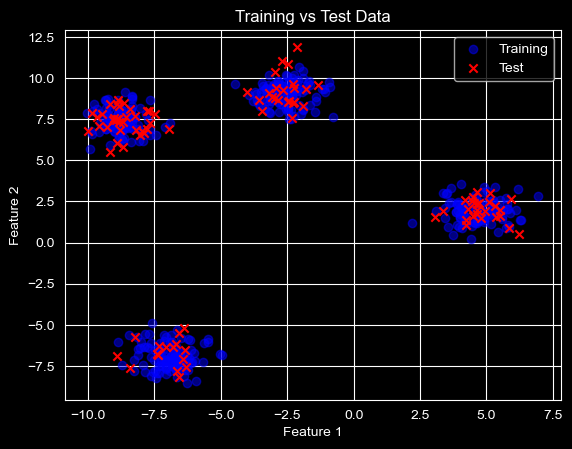

In [21]:
#Get a Dataset to use as experience data
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


import numpy as np
data, labels = make_blobs(
n_samples=500,
centers=4,
cluster_std=0.75,
random_state=42)




#Split your data into training and test data
experienceData,testData, experienceLabels, testLabels = train_test_split(data,labels, test_size=0.20)
len(experienceLabels)


# Plot training data
plt.scatter(experienceData[:, 0], experienceData[:, 1], marker='o', c='blue', alpha=0.5, label='Training')

# Plot test data
plt.scatter(testData[:, 0], testData[:, 1], marker='x', c='red', label='Test')

plt.legend()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Training vs Test Data')
plt.show()

In [22]:
def knn_predict(new_point, experience_data, experience_labels, k):
    """
    K-Nearest Neighbors prediction function.
    
    Parameters:
    -----------
    new_point : array-like, shape (n_features,)
        The point to classify
    experience_data : array-like, shape (n_samples, n_features)
        Training data points
    experience_labels : array-like, shape (n_samples,)
        Labels for training data
    k : int
        Number of nearest neighbors to consider
    
    Returns:
    --------
    predicted_class : int
        The predicted class label
    
    Steps to implement:
    1. Calculate Euclidean distance from new_point to all points in experience_data
       Hint: Use np.sqrt(np.sum((experience_data - new_point)**2, axis=1))
    2. Find the indices of the k smallest distances
       Hint: Use np.argsort(distances)[:k]
    3. Get the labels of these k nearest neighbors
    4. Return the most common label (majority vote)
       Hint: Use np.bincount(labels).argmax() or statistics.mode()
    """
    
    # Step 1: Calculate distances
    distances = ?  # TODO: Calculate Euclidean distance to all experience points
    
    # Step 2: Find k nearest neighbors
    k_nearest_indices = ?  # TODO: Get indices of k smallest distances
    
    # Step 3: Get labels of k nearest neighbors
    k_nearest_labels = ?  # TODO: Get the labels of the k nearest points
    
    # Step 4: Return majority class
    predicted_class = ?  # TODO: Find the most common label
    
    return predicted_class

SyntaxError: invalid syntax (1270468127.py, line 32)

In [ ]:
# Test your KNN implementation on a few test points
# Try with k=3 and k=5 to see how the parameter affects predictions

k = 5  # Number of neighbors

# Predict for the first 5 test points
print("Testing KNN implementation:")
print(f"Using k={k} neighbors\n")

for i in range(5):
    prediction = knn_predict(testData[i], experienceData, experienceLabels, k)
    actual = testLabels[i]
    print(f"Point {i}: Predicted={prediction}, Actual={actual}, {'✓' if prediction == actual else '✗'}")

### Using Scikit-Learn's KNN

While implementing KNN from scratch helps understand the algorithm, in practice we use optimized implementations like scikit-learn's `KNeighborsClassifier`.

**Advantages of sklearn's implementation:**
- Highly optimized (uses efficient data structures like KD-trees)
- Supports different distance metrics
- Easy to use with consistent API
- Built-in cross-validation and parameter tuning

[Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create and train the KNN classifier
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(experienceData, experienceLabels)

# Make predictions on test data
y_pred_knn = knn_classifier.predict(testData)

# Evaluate the model
accuracy = accuracy_score(testLabels, y_pred_knn)
print(f"KNN Accuracy: {accuracy:.4f}")
print(f"Correctly classified: {sum(y_pred_knn == testLabels)} out of {len(testLabels)} test samples")

In [ ]:
# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(testLabels, y_pred_knn)
print(cm)

print("\nClassification Report:")
print(classification_report(testLabels, y_pred_knn))

### Task 2 (Optional): Visualize Decision Boundaries

Create a visualization that shows:
1. Training data points (with their true labels)
2. Test data points (with their true labels)
3. Decision boundaries created by the KNN classifier

**Hint:** You'll need to:
- Create a mesh grid covering the feature space
- Predict the class for each point in the grid
- Use `plt.contourf()` to visualize decision regions

In [ ]:
# Solution for decision boundary visualization
import numpy as np
import matplotlib.pyplot as plt

# Create a mesh grid
h = 0.1  # step size in the mesh
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Predict for each point in the mesh
Z = knn_classifier.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(experienceData[:, 0], experienceData[:, 1], 
           c=experienceLabels, marker='o', s=50, edgecolors='k',
           cmap='viridis', alpha=0.7, label='Training')
plt.scatter(testData[:, 0], testData[:, 1], 
           c=testLabels, marker='s', s=80, edgecolors='red',
           cmap='viridis', label='Test')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title(f'KNN Decision Boundaries (k={knn_classifier.n_neighbors})')
plt.legend()
plt.colorbar(label='Class')
plt.show()

---

## 2. Support Vector Machines (SVM)

### What is SVM?
Support Vector Machines is a powerful supervised learning algorithm used for classification and regression. It finds the optimal boundary (hyperplane) that separates different classes with the **maximum margin**.

**How it works:**
1. Find the hyperplane that best separates the classes
2. Maximize the margin (distance) between the hyperplane and the nearest data points (support vectors)
3. Use kernel tricks to handle non-linear decision boundaries

**Key Parameters:**
- `kernel`: Type of kernel function ('linear', 'rbf', 'poly', 'sigmoid')
  - `'linear'`: Good for linearly separable data
  - `'rbf'` (Radial Basis Function): Good for non-linear data (default)
  - `'poly'`: Polynomial kernel for curved boundaries
- `C`: Regularization parameter (controls trade-off between margin and misclassification)

### Example: Breast Cancer Classification

We'll use the [Wisconsin Breast Cancer dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#breast-cancer-wisconsin-diagnostic-dataset) to classify tumors as malignant (0) or benign (1).

[SVM Documentation](https://scikit-learn.org/stable/modules/svm.html)

In [ ]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
import pandas as pd
cancer=datasets.load_breast_cancer(as_frame=True)

X = cancer.data
y = cancer.target

# print the cancer data features (top 5 records)
print(X.describe())
# print the cancer labels (0:malignant, 1:benign
print(y.value_counts())

### Interpreting the Results

The confusion matrix shows:
- **True Negatives** (top-left): Malignant correctly classified
- **False Positives** (top-right): Benign incorrectly classified as malignant
- **False Negatives** (bottom-left): Malignant incorrectly classified as benign
- **True Positives** (bottom-right): Benign correctly classified

The classification report provides:
- **Precision**: Of all predicted positive, how many are truly positive?
- **Recall**: Of all actual positive, how many did we find?
- **F1-Score**: Harmonic mean of precision and recall

### Visualizing the Decision Boundary

For 2D data, we can visualize how SVM separates the classes.

In [ ]:
from sklearn.model_selection import train_test_split

#split data into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

#train the SVC classifier
clf = svm.SVC(kernel= "linear")
clf.fit(X_train,y_train)

In [ ]:
#predict labels on the test data using our classifier
y_pred = clf.predict(X_test)
print(y_pred)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

#compare our predictions to the true labels
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Creating a random 2D dataset for visualization
# 2,000 samples with 2 features (for 2D visualization)
# Binary classification (2 classes: 0 and 1)
X, y = make_classification(n_samples=2000, n_features=2,
                           n_informative=2, n_redundant=0,
                           n_classes=2,
                           random_state=32)

# Visualize the dataset
sns.scatterplot(x=X[:, 0],
                y=X[:, 1],
                hue=y,
                s=8)
plt.title('2D Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# Split dataset into train and test
# stratify ensures balanced class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                   test_size=0.3, stratify=y,
                                   random_state=32)

# Train SVM with linear kernel
svc_model = SVC(kernel='linear', random_state=32)
svc_model.fit(X_train, y_train)

print(f"Training accuracy: {svc_model.score(X_train, y_train):.4f}")
print(f"Test accuracy: {svc_model.score(X_test, y_test):.4f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(10, 8))

# Plot the training data
sns.scatterplot(x=X_train[:, 0],
                y=X_train[:, 1],
                hue=y_train,
                s=30,
                alpha=0.6)

# Extract hyperplane parameters from the trained model
# For a linear SVM: w·x + b = 0
w = svc_model.coef_[0]  # Weights (w0, w1)
b = svc_model.intercept_[0]  # Bias term

# Create x-coordinates for the decision boundary line
x_points = np.linspace(X_train[:, 0].min(), X_train[:, 0].max(), 100)

# Calculate y-coordinates using: w0*x + w1*y + b = 0 => y = -(w0*x + b)/w1
y_points = -(w[0] / w[1]) * x_points - b / w[1]

# Plot the decision boundary (hyperplane)
plt.plot(x_points, y_points, 'r-', linewidth=2, label='Decision Boundary')

# Calculate and plot the margins
# Support vectors lie on: w·x + b = ±1
margin = 1 / w[1]
y_margin_down = y_points - margin
y_margin_up = y_points + margin

plt.plot(x_points, y_margin_down, 'r--', linewidth=1, alpha=0.5, label='Margin')
plt.plot(x_points, y_margin_up, 'r--', linewidth=1, alpha=0.5)

plt.title('SVM Decision Boundary with Margins')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

---

## 3. Decision Trees

### What are Decision Trees?
Decision Trees are intuitive classifiers that make decisions by asking a series of questions about the features. They create a tree-like structure where:
- **Internal nodes** represent feature tests (questions)
- **Branches** represent the outcome of the test
- **Leaf nodes** represent class labels

**How it works:**
1. Start at the root with all data
2. Find the best feature to split on (maximizes information gain or minimizes Gini impurity)
3. Create branches for each possible value/range
4. Repeat recursively for each branch until stopping criteria is met

**Advantages:**
- Easy to understand and interpret (white-box model)
- Requires little data preprocessing
- Can handle both numerical and categorical data
- Non-parametric (no assumptions about data distribution)

**Disadvantages:**
- Prone to overfitting (especially deep trees)
- Can be unstable (small data changes can lead to different trees)
- May create biased trees if some classes dominate

**Key Parameters:**
- `max_depth`: Maximum depth of the tree (controls overfitting)
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required in a leaf node
- `criterion`: Function to measure split quality ('gini' or 'entropy')

[Documentation](https://scikit-learn.org/stable/modules/tree.html)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Load the Iris dataset (classic multi-class classification problem)
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Display dataset info
print("Iris Dataset:")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")
print(f"Samples: {len(X_iris)}")

# Create DataFrame for better visualization
iris_df = pd.DataFrame(X_iris, columns=iris.feature_names)
iris_df['species'] = [iris.target_names[i] for i in y_iris]
print("\nFirst few samples:")
print(iris_df.head())

In [ ]:
# Split the data
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Create and train a Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(
    max_depth=3,           # Limit depth to avoid overfitting
    criterion='gini',      # Use Gini impurity
    random_state=42
)

dt_classifier.fit(X_train_iris, y_train_iris)

# Make predictions
y_pred_dt = dt_classifier.predict(X_test_iris)

# Evaluate
train_accuracy = dt_classifier.score(X_train_iris, y_train_iris)
test_accuracy = dt_classifier.score(X_test_iris, y_test_iris)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_iris, y_pred_dt, target_names=iris.target_names))

### Visualizing the Decision Tree

One of the major advantages of decision trees is their interpretability. We can visualize the entire decision-making process!

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,           # Color nodes by majority class
          rounded=True,          # Rounded box style
          fontsize=10)
plt.title("Decision Tree for Iris Classification", fontsize=16)
plt.show()

### Feature Importance

Decision trees can tell us which features are most important for making predictions.

In [ ]:
# Get feature importances
importances = dt_classifier.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance in Decision Tree')
plt.gca().invert_yaxis()  # Highest importance at the top
plt.tight_layout()
plt.show()

### Task 3: Exploring Overfitting

Decision trees can easily overfit if they become too deep. Let's explore this!

**Your task:**
1. Train decision trees with different `max_depth` values (e.g., 1, 3, 5, 10, None)
2. Compare training vs test accuracy for each
3. Observe how overfitting occurs as depth increases

**Questions to consider:**
- What happens when `max_depth=None`? (unlimited depth)
- At what depth does the model start to overfit?
- What's the best depth for this dataset?

In [ ]:
# Solution: Exploring different depths
depths = [1, 2, 3, 5, 10, None]
train_scores = []
test_scores = []

for depth in depths:
    # Train a tree with this depth
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_iris, y_train_iris)
    
    # Record scores
    train_acc = dt.score(X_train_iris, y_train_iris)
    test_acc = dt.score(X_test_iris, y_test_iris)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
    depth_str = str(depth) if depth is not None else "None"
    print(f"Depth={depth_str:4s}: Train={train_acc:.4f}, Test={test_acc:.4f}, Gap={train_acc-test_acc:.4f}")

# Visualize the results
plt.figure(figsize=(10, 6))
x_labels = [str(d) if d is not None else "None" for d in depths]
x_pos = range(len(depths))

plt.plot(x_pos, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(x_pos, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xticks(x_pos, x_labels)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Test Accuracy for Different Tree Depths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nObservation: As depth increases, training accuracy improves but test accuracy may plateau or decrease.")
print("This gap indicates overfitting - the model memorizes training data rather than learning patterns.")

---

## 4. Model Comparison and Selection

Now that we've explored three different classification algorithms, let's compare them side-by-side to understand their strengths and when to use each.

### Comparing KNN, SVM, and Decision Trees on the Iris Dataset

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Define the models to compare
models = {
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'SVM (linear)': SVC(kernel='linear', random_state=42),
    'SVM (rbf)': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42)
}

# Store results
results = []

for name, model in models.items():
    # Train the model and measure time
    start_time = time.time()
    model.fit(X_train_iris, y_train_iris)
    training_time = time.time() - start_time
    
    # Make predictions
    y_pred = model.predict(X_test_iris)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_iris, y_pred)
    precision = precision_score(y_test_iris, y_pred, average='weighted')
    recall = recall_score(y_test_iris, y_pred, average='weighted')
    f1 = f1_score(y_test_iris, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_time
    })

# Create a comparison DataFrame
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(4)
print("Model Comparison Results:")
print(comparison_df.to_string(index=False))

In [ ]:
# Visualize the comparison
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy comparison
ax1 = axes[0]
bars = ax1.bar(comparison_df['Model'], comparison_df['Accuracy'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy Comparison')
ax1.set_ylim([0.8, 1.0])
ax1.tick_params(axis='x', rotation=45)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom')

# Plot 2: All metrics comparison
ax2 = axes[1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    offset = width * (i - 1.5)
    ax2.bar(x + offset, comparison_df[metric], width, label=metric)

ax2.set_ylabel('Score')
ax2.set_title('Comprehensive Metrics Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax2.legend()
ax2.set_ylim([0.8, 1.0])

plt.tight_layout()
plt.show()

### When to Use Each Algorithm?

Choosing the right algorithm depends on your data characteristics and requirements:

#### **K-Nearest Neighbors (KNN)**

**Best for:**
- Small to medium-sized datasets
- When the decision boundary is irregular
- When you need a simple baseline model
- Real-time prediction is not critical

**Pros:**
- Simple and intuitive
- No training phase (lazy learning)
- Works well with low-dimensional data
- Non-parametric (no assumptions about data)

**Cons:**
- Slow prediction time (must compute distances to all points)
- Sensitive to irrelevant features and scale
- Requires feature normalization
- Poor with high-dimensional data (curse of dimensionality)

---

#### **Support Vector Machines (SVM)**

**Best for:**
- High-dimensional data (many features)
- Clear margin of separation exists
- When you need robust classification
- Small to medium datasets

**Pros:**
- Effective in high-dimensional spaces
- Memory efficient (uses support vectors only)
- Versatile (different kernel functions)
- Works well with clear margin of separation

**Cons:**
- Slow training on large datasets
- Sensitive to parameter tuning (C, gamma, kernel)
- Difficult to interpret (black-box model)
- Requires feature scaling

---

#### **Decision Trees**

**Best for:**
- When interpretability is important
- Mixed data types (numerical and categorical)
- When feature interactions matter
- Non-linear relationships

**Pros:**
- Easy to understand and interpret
- Requires little data preprocessing
- Can handle non-linear relationships
- Feature importance is built-in
- Works with missing values

**Cons:**
- Prone to overfitting (especially deep trees)
- Unstable (small data changes can cause big tree changes)
- Biased with imbalanced datasets
- Not always the most accurate

---

### General Guidelines

1. **Start simple**: Begin with logistic regression or decision trees
2. **Try multiple models**: Compare KNN, SVM, and tree-based methods
3. **Consider ensemble methods**: Random Forests, Gradient Boosting (covered in advanced topics)
4. **Validate properly**: Use cross-validation, not just train/test split
5. **Scale your features**: Especially important for KNN and SVM
6. **Tune hyperparameters**: Use grid search or random search

### The "No Free Lunch" Theorem

There is no single best algorithm for all problems. The best model depends on:
- Dataset size and dimensionality
- Data quality and noise level
- Feature types and distributions
- Computational resources
- Interpretability requirements
- Prediction speed requirements

---

## 5. Practice Exercises

### Exercise 1: Titanic Survival Prediction
Use the Titanic dataset (`datasets/titanic.csv`) to predict passenger survival.

**Tasks:**
1. Load and explore the Titanic dataset
2. Preprocess the data (handle missing values, encode categorical variables)
3. Train all three classifiers (KNN, SVM, Decision Tree)
4. Compare their performance
5. Which model works best and why?

### Exercise 2: Parameter Tuning
For the Iris dataset:
1. Experiment with different `k` values for KNN (try k=1, 3, 5, 7, 9, 11)
2. Try different SVM kernels ('linear', 'rbf', 'poly') and C values
3. Experiment with Decision Tree parameters (max_depth, min_samples_split)
4. Plot how each parameter affects accuracy

### Exercise 3: Real-World Application
Choose a dataset from [scikit-learn's datasets](https://scikit-learn.org/stable/datasets.html) or [Kaggle](https://www.kaggle.com/datasets):
1. Define the classification problem
2. Perform exploratory data analysis
3. Build and compare multiple models
4. Document your findings and model selection rationale

---

## Summary

In this notebook, you learned about:

1. **K-Nearest Neighbors (KNN)**
   - Instance-based learning
   - Distance metrics and the importance of k
   - Implementation from scratch and with scikit-learn

2. **Support Vector Machines (SVM)**
   - Finding optimal decision boundaries
   - Kernel tricks for non-linear classification
   - Margin maximization

3. **Decision Trees**
   - Rule-based classification
   - Feature importance and interpretability
   - Overfitting and the bias-variance tradeoff

4. **Model Comparison**
   - How to evaluate and compare different models
   - When to use each algorithm
   - The importance of trying multiple approaches

**Next Steps:**
- Explore ensemble methods (Random Forests, Gradient Boosting)
- Learn about cross-validation and hyperparameter tuning
- Practice with real-world datasets
- Study deep learning for complex classification tasks